## Setup

**On SWAN:** in the SIDM_abbott project terminal, run `bash setup_swan.sh` if you haven't already, then select
**Python (SIDM SWAN)** and restart the notebook kernel. If you already have a valid
CMS proxy on SWAN, you can use `bash setup_swan.sh --use-existing-proxy` instead.
See [SWAN_SETUP.md](../../../SWAN_SETUP.md) for certificate setup and renewal.

**On coffea-casa:** use the usual setup and Python kernel.
The compatibility cell below reads `RUNNING_ON_SWAN` and checks SWAN setup/proxy
validity when enabled. Its `running_on_swan` result selects FNAL EOS or the default
coffea-casa xcache in each fileset. Analysis and plotting are the same.


In [1]:
# python
import sys
import importlib
# columnar analysis
from coffea import processor
# local
from pathlib import Path
# Import SIDM from this notebook's checkout, even when multiple clones exist.
sidm_path = next((p for p in (Path.cwd(), *Path.cwd().parents)
                  if (p / "sidm" / "tools").is_dir() and (p / "setup.py").is_file()), None)
if sidm_path is None:
    raise RuntimeError("Start this notebook inside your SIDM checkout.")
sys.path.insert(0, str(sidm_path))

from sidm.tools import sidm_processor, llpnanoaodschema, utilities
importlib.reload(sidm_processor)
importlib.reload(llpnanoaodschema)
importlib.reload(utilities)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
import numpy as np
#suppress divide by zero warnings for all of the ratio plots
np.seterr(divide='ignore', invalid='ignore')
import hist
import matplotlib.colors as mcolors

In [2]:
# File-access compatibility and environment diagnostic.
from sidm.tools.swan import configure_notebook
running_on_swan = configure_notebook()  # reads RUNNING_ON_SWAN; default is coffea-casa

import coffea
print("Notebook Python:", sys.executable)
print("Coffea version:", coffea.__version__)

print("SIDM checkout:", sidm_path)


File access: coffea-casa xcache (default).
Notebook Python: /usr/local/bin/python
Coffea version: 2025.11.0
SIDM checkout: /home/cms-jovyan/SIDM_abbott


In [3]:
samples = [
    '2Mu2E_200GeV_0p25GeV_10p0mm',
    '2Mu2E_200GeV_0p25GeV_0p01mm',
    '2Mu2E_200GeV_5p0GeV_2p0mm',
    '2Mu2E_200GeV_5p0GeV_200p0mm',
    '2Mu2E_500GeV_0p25GeV_0p04mm',
    '2Mu2E_500GeV_5p0GeV_0p8mm',
    '2Mu2E_800GeV_0p25GeV_0p025mm',
    '2Mu2E_800GeV_0p25GeV_2p5mm',
    '2Mu2E_1000GeV_0p25GeV_0p02mm'
]
    
fileset = utilities.make_fileset(samples, "llpNanoAOD_v2", max_files = 1, location_cfg="signal_2mu2e_v10.yaml", replace_xcache=running_on_swan)

In [4]:
runner = processor.Runner(
    executor=processor.IterativeExecutor(),
    #executor=processor.FuturesExecutor(),
    schema=llpnanoaodschema.LLPNanoAODSchema,
    maxchunks=1,
    skipbadfiles=True
)

channels = [
    "baseNoLj",
    "baseNoLj_noTrigger",
    "base_noMuPtCut",
    "base",
    "2mu2e_PhotonNumerator",
    "2mu2e_PhotonDenominator"
]
p = sidm_processor.SidmProcessor(
    channels,
    ["lj_base","mu_lj_base", "trig_base","genMu_base","genA_toMu_base","genA_base","dsaMuon_base"],
    #verbose=True,
    unweighted_hist=True,
)

output = runner.run(fileset, treename='Events', processor_instance=p)
out = output["out"]

Output()

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

...

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

Warning: Unable to apply all for nested dsaMuons collection. Skipping.... no field named 'good_matched_muons'

2Mu2E_200GeV_0p25GeV_10p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_200GeV_0p25GeV_0p01mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_200GeV_5p0GeV_2p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_200GeV_5p0GeV_200p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_500GeV_0p25GeV_0p04mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_500GeV_5p0GeV_0p8mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_800GeV_0p25GeV_0p025mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_800GeV_0p25GeV_2p5mm is simulation. Scaling histograms or cutflows according to 

In [5]:
from coffea.nanoevents import NanoEventsFactory
from sidm.tools import llpnanoaodschema

# Extract the actual .root file path from your fileset dictionary
sample_name = '2Mu2E_200GeV_0p25GeV_10p0mm'
fileset_2mu2e = utilities.make_fileset(samples, "llpNanoAOD_v2", max_files=1, location_cfg="signal_2mu2e_v10.yaml", replace_xcache=running_on_swan)
test_file = fileset_2mu2e[sample_name]['files'][0]

# # Open the file using your framework's custom schema
# events = NanoEventsFactory.from_root(
#     {test_file: "Events"},
#     # test_file,
#     # treepath='Events',
#     schemaclass=llpnanoaodschema.LLPNanoAODSchema
# ).events()

# # Filter specifically for photon or electron triggers
# photon_triggers = [t for t in events.hlt.fields if "photon" in t.lower()]
# ele_triggers = [t for t in events.hlt.fields if "ele" in t.lower()]

# print("Photon triggers found:", photon_triggers)
# print("Electron triggers found:", ele_triggers)

In [6]:
#Define a function to plot a row of ratio plots
def plot_ratio_row(nums, dens, sample,**kwargs):
    """
    Plots n ratio plots in a single row.
    nums: list of numerators (each can be a hist or a list of hists)
    dens: list of denominators (hists)
    """
    n = len(dens)

    
    # Lower-panel label/limits default to the efficiency convention but can be
    # overridden for a generic ratio; popped so they do not reach hep.histplot.
    ratio_ylabel = kwargs.pop("ratio_ylabel", "Efficiency")
    ratio_ylim = kwargs.pop("ratio_ylim", (0, 1.2))
    
    # squeeze=False guarantees axes is always shape (2, n)
    # sharex='col' shares the x-axis vertically but not horizontally
    fig, axes = plt.subplots(
        2, n, figsize=(12 * n, 15), sharex='col',
        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0},
        squeeze=False, layout="constrained"
    )

    for i in range(n):
        ax1 = axes[0, i]
        ax2 = axes[1, i]
        
        den = dens[i]
        num = nums[i]
        
        plt.sca(ax1)
        sam = sample
        
        # Handle kwargs that might be passed as lists (one for each column)
        label = None
        if "legend" in kwargs:
            label = kwargs["legend"][i] if isinstance(kwargs["legend"], list) else kwargs["legend"][0]

        utilities.plot(den, flow='none', color="k", skip_label=True, label=label)

        if not isinstance(num, list):
            num = [num]

        for x in num:
            utilities.plot(x, flow='none', label=label)

        if "legend" in kwargs:
            title = kwargs["text"][i] if "text" in kwargs and isinstance(kwargs["text"], list) else kwargs.get("text")
            ax1.legend(title=title, alignment="left")

        if "ylim" in kwargs:
            ax1.set_ylim(kwargs["ylim"])

        if i ==0:
            ax1.text(0.97, 0.97, sam, 
                transform=ax1.transAxes, 
                fontsize=25, 
                color='black',
                ha='right', 
                va='bottom')
            
        # Only draw the y-axis label on the leftmost plot to keep the row clean
        if "ylabel" in kwargs and i == 0:
            ax1.set_ylabel(kwargs["ylabel"])


        plt.sca(ax2)
        for x in num:
            try:
                eff, errors = utilities.get_eff_hist(x, den)
            except ValueError:
                # num is not a subset of den (a shape ratio, not an efficiency): the
                # binomial Clopper-Pearson interval is invalid and ratio_uncertainty
                # raises -- fall back to a Gaussian-propagated ratio.
                eff, errors = _gaussian_ratio(x, den)
            utilities.plot(eff, histtype='errorbar', yerr=errors, skip_label=True)

        # Only draw the ratio y-axis label on the leftmost plot
        if i == 0:
            ax2.set_ylabel(ratio_ylabel)
            
        if ratio_ylim is not None:
            ax2.set_ylim(*ratio_ylim)

        if "xlabel" in kwargs:
            # Handle if they pass a list of xlabels (one per column) or just one string
            xlabel = kwargs["xlabel"][i] if isinstance(kwargs["xlabel"], list) else kwargs["xlabel"]
            ax2.set_xlabel(xlabel)


    return fig, axes

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variance

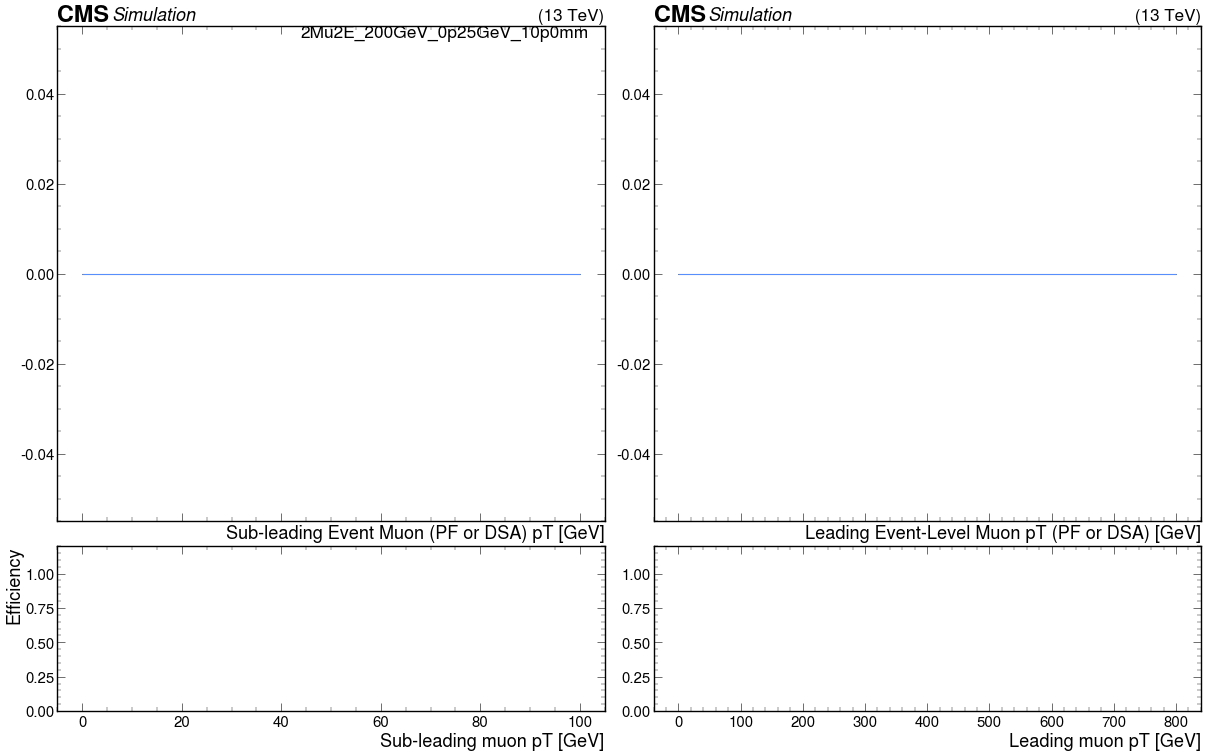

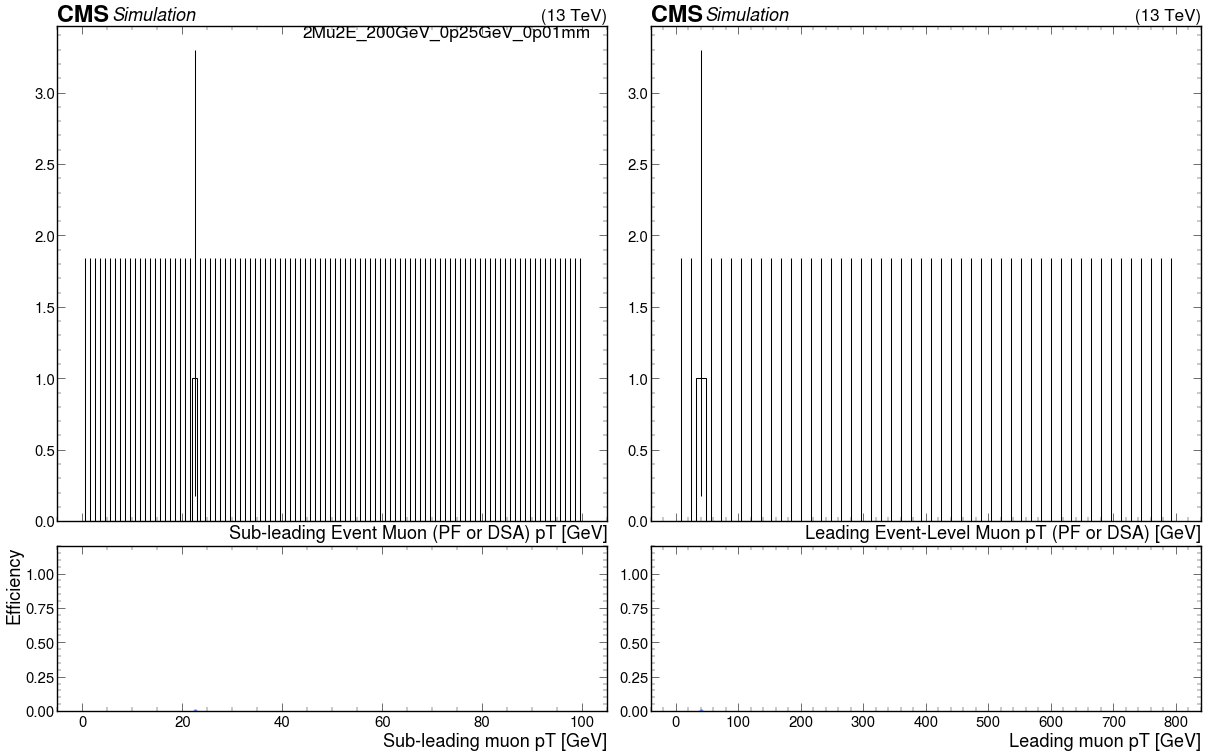

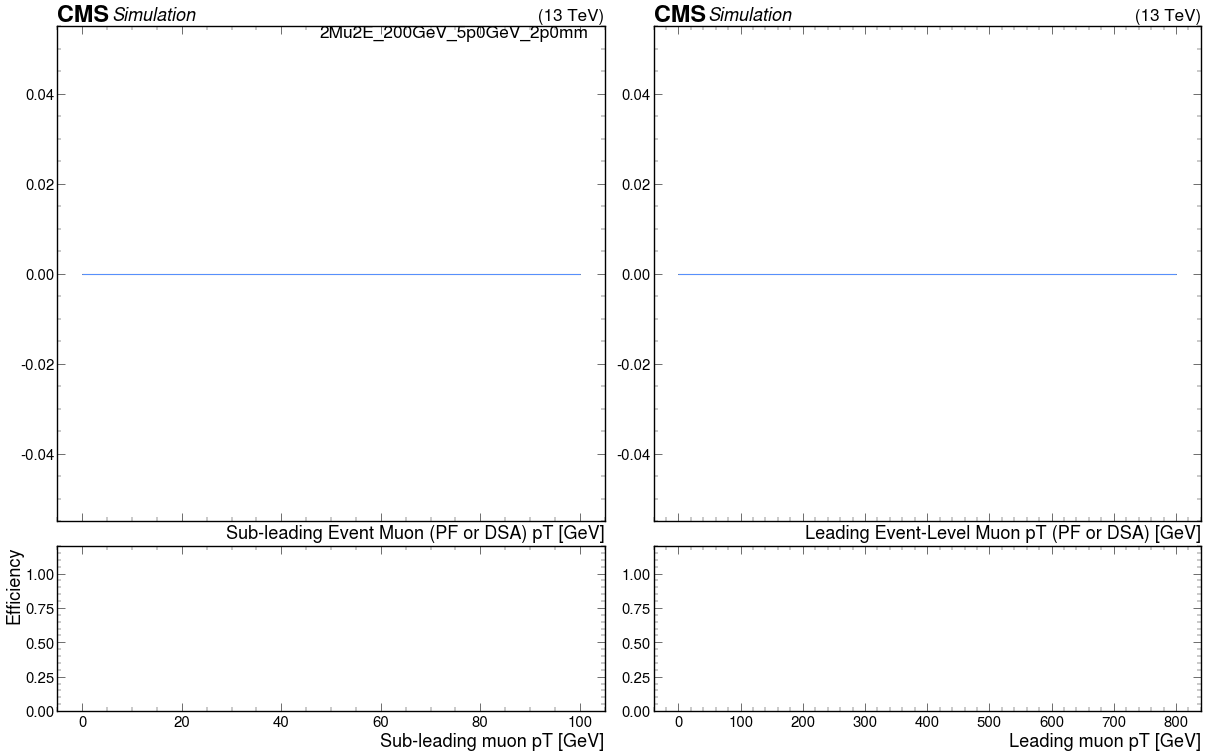

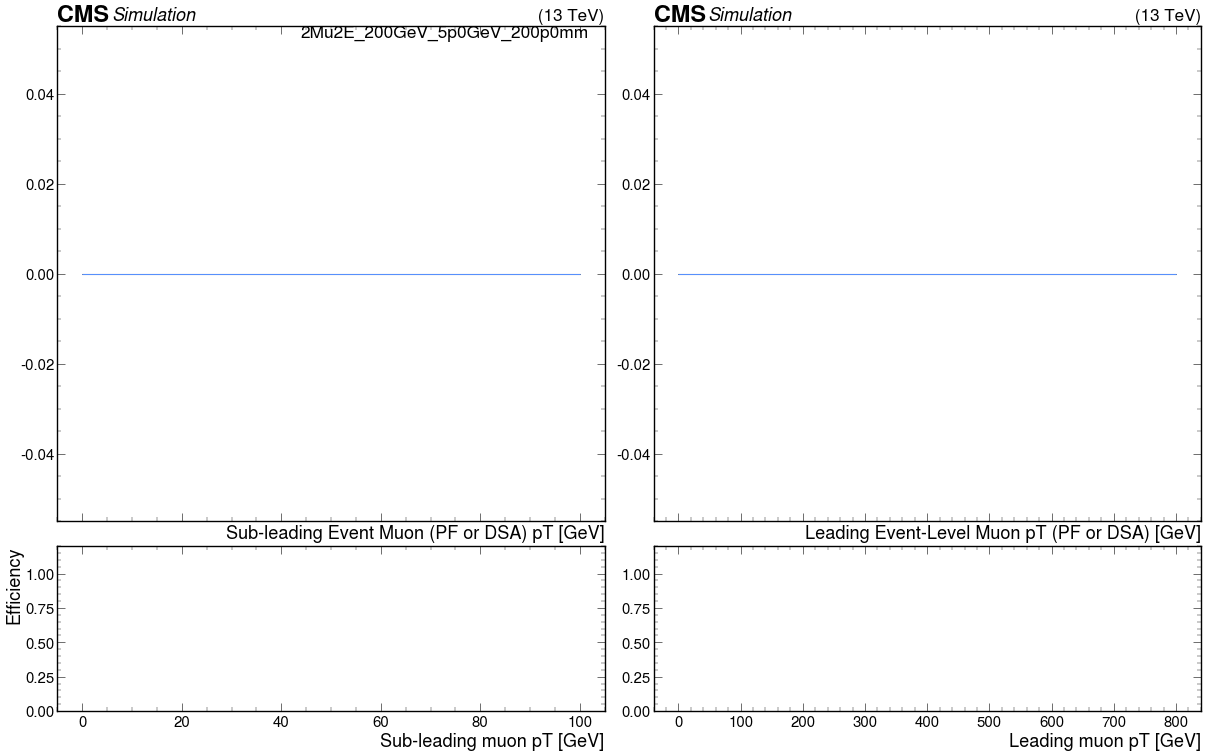

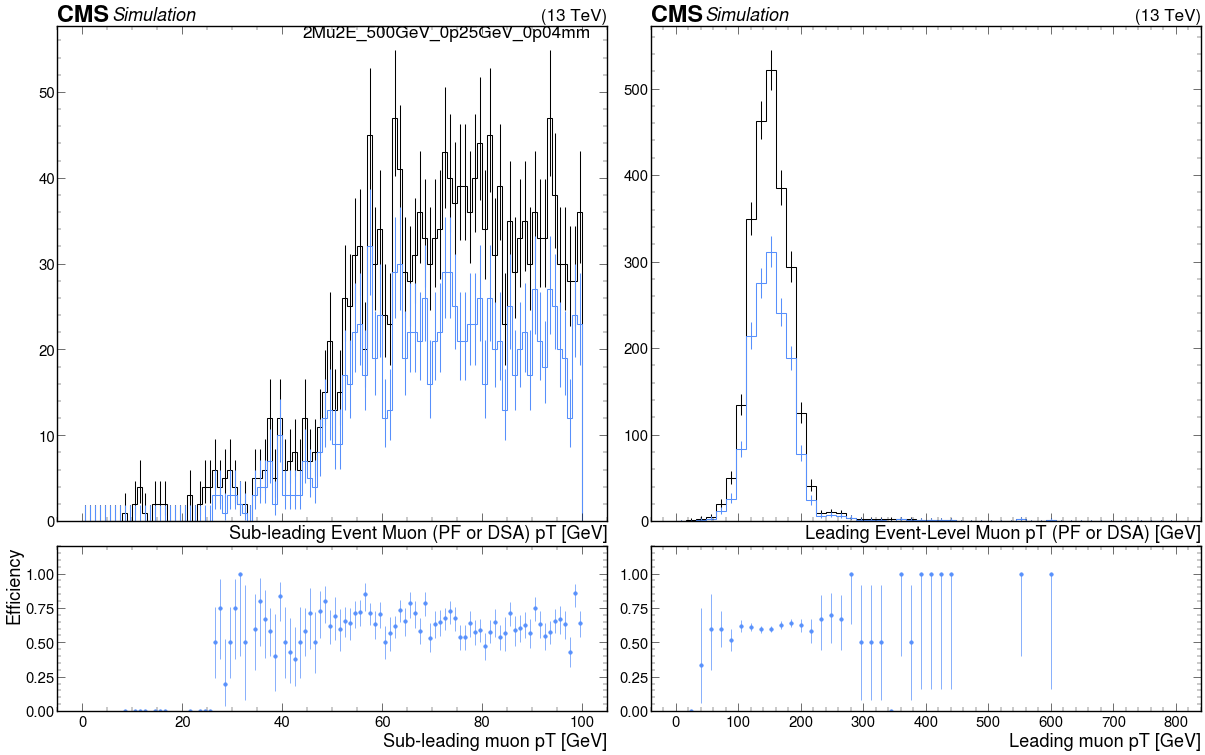

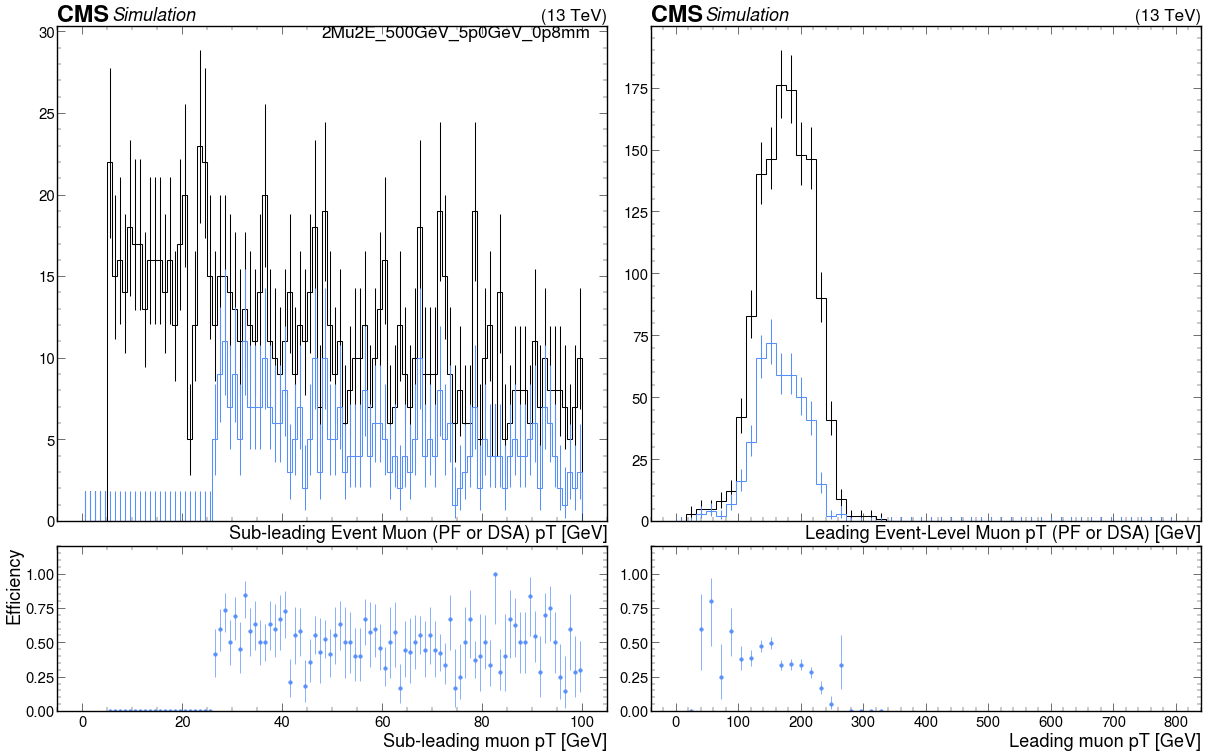

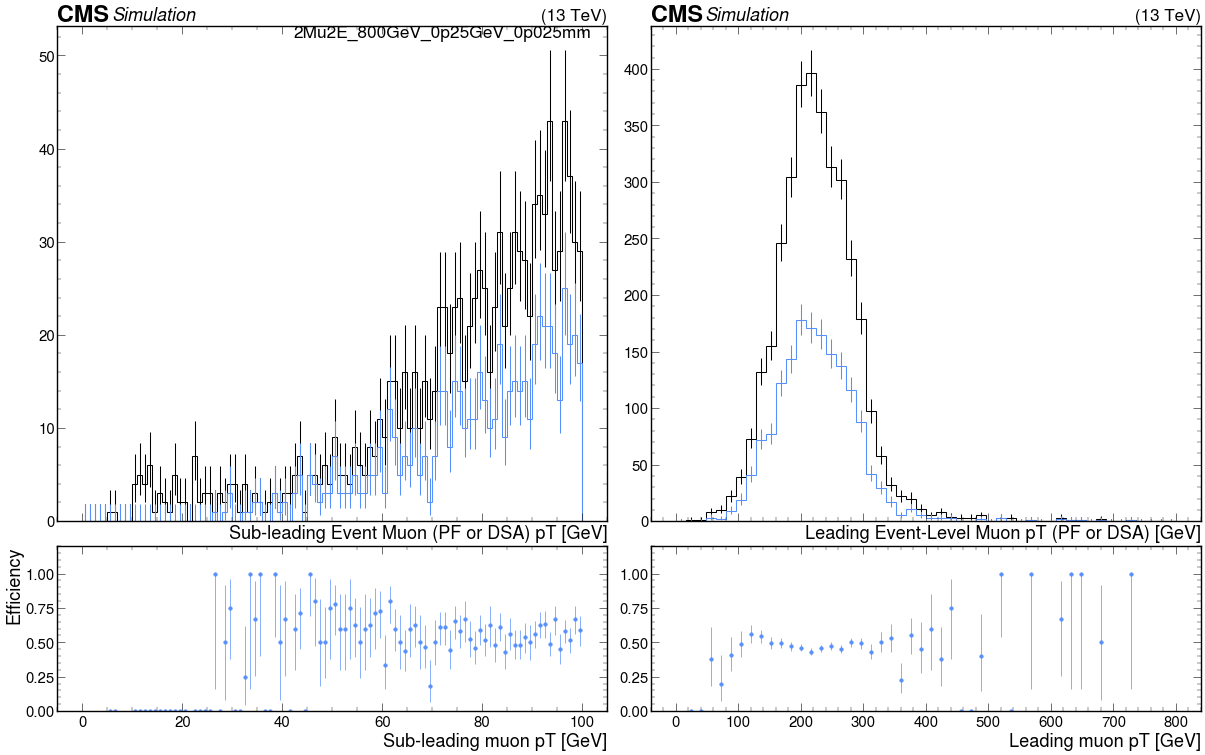

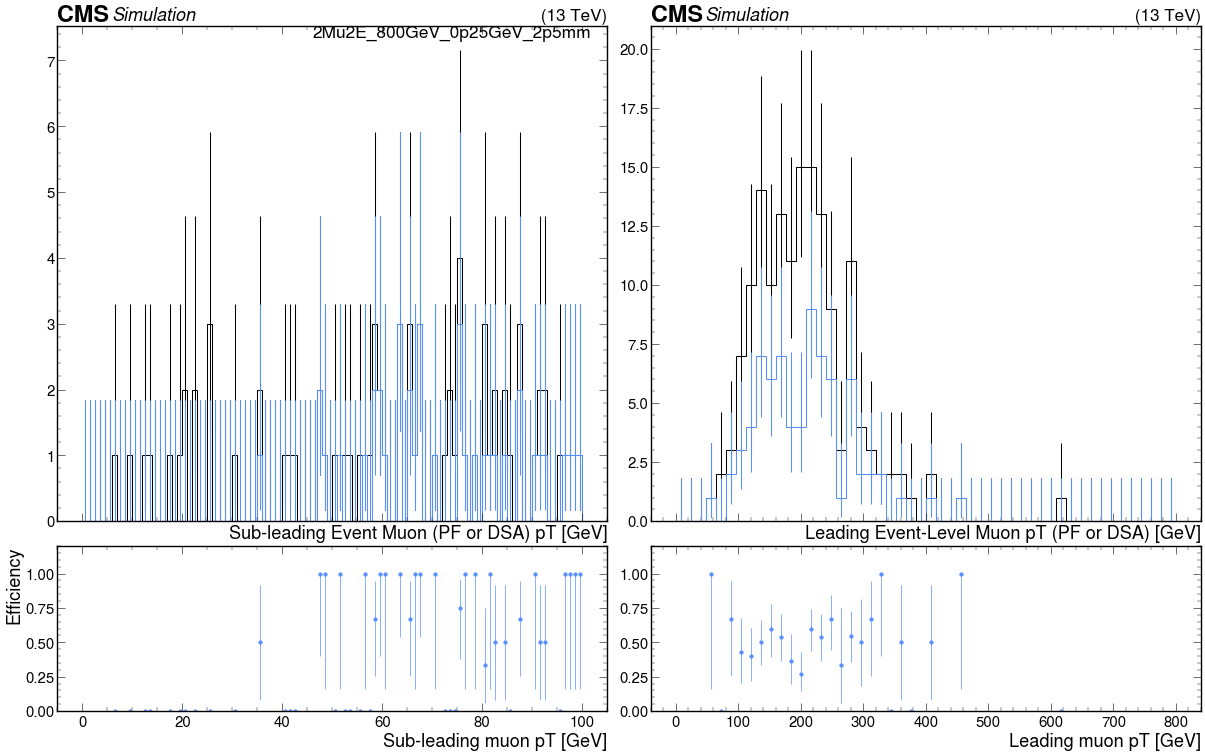

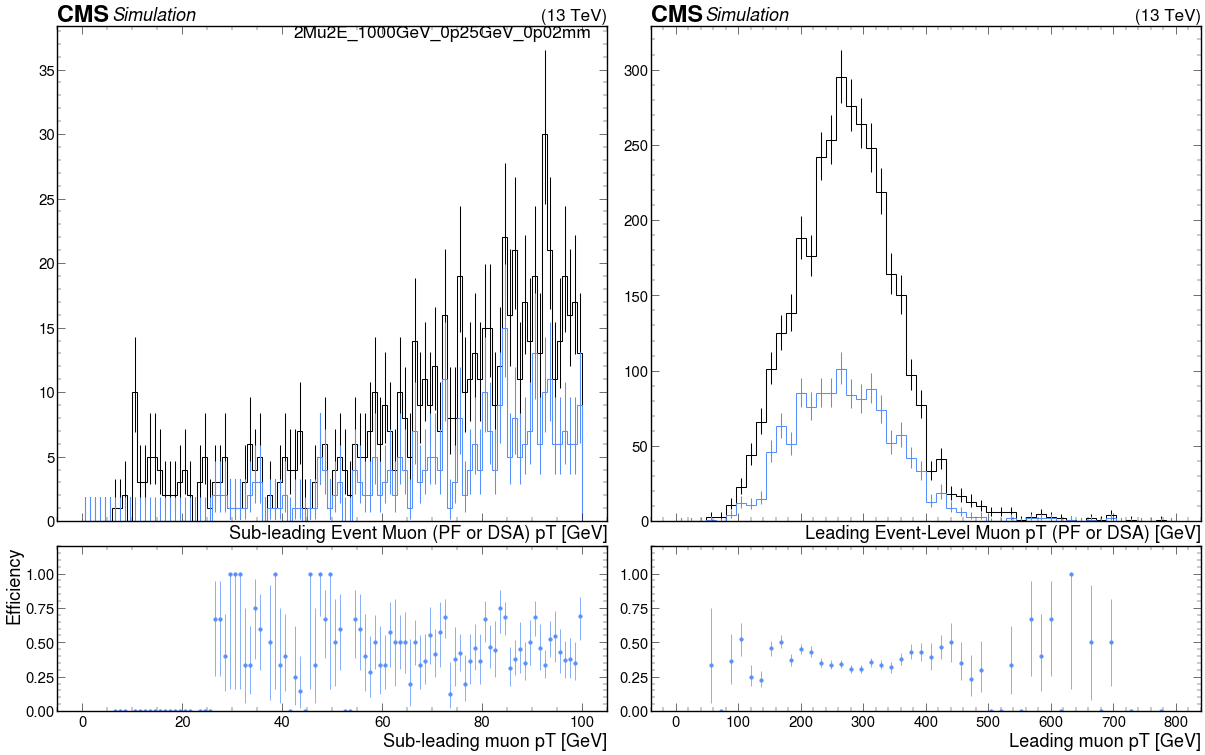

In [7]:
num_ch = "2mu2e_PhotonNumerator"
denom_ch = "2mu2e_PhotonDenominator"
plot_name = "all_muon0_pt_vs_all_muon1_pt"

for sample in samples:
    nums = [out[sample]["hists"][plot_name][ num_ch, sum,:],
            out[sample]["hists"]["leading_event_muon_pt"][num_ch, :],
           ]
    denoms = [out[sample]["hists"][plot_name][denom_ch, sum,:],
              out[sample]["hists"]["leading_event_muon_pt"][denom_ch, :],
             ]
              
    plot_ratio_row(nums,denoms,sample,xlabel=["Sub-leading muon pT [GeV]","Leading muon pT [GeV]"])

Plan: Efficiencies for data and MC, make scale factor hist with those for Delta R.

/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variance

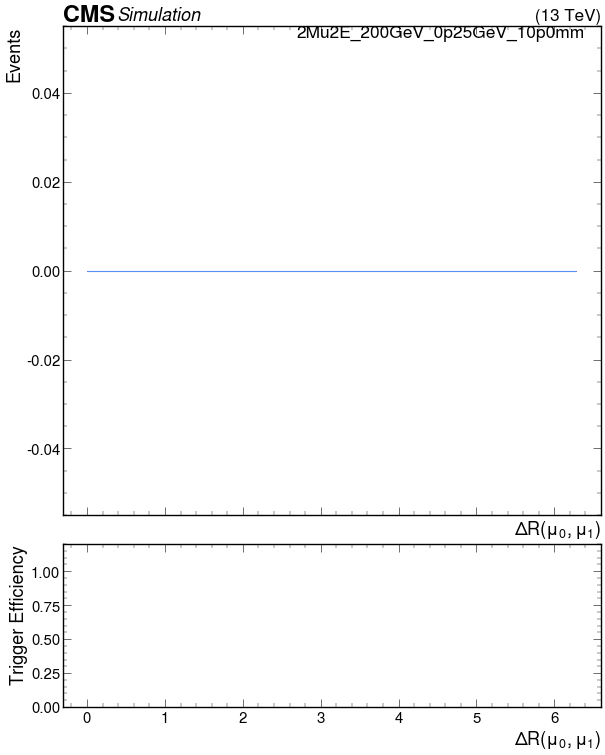

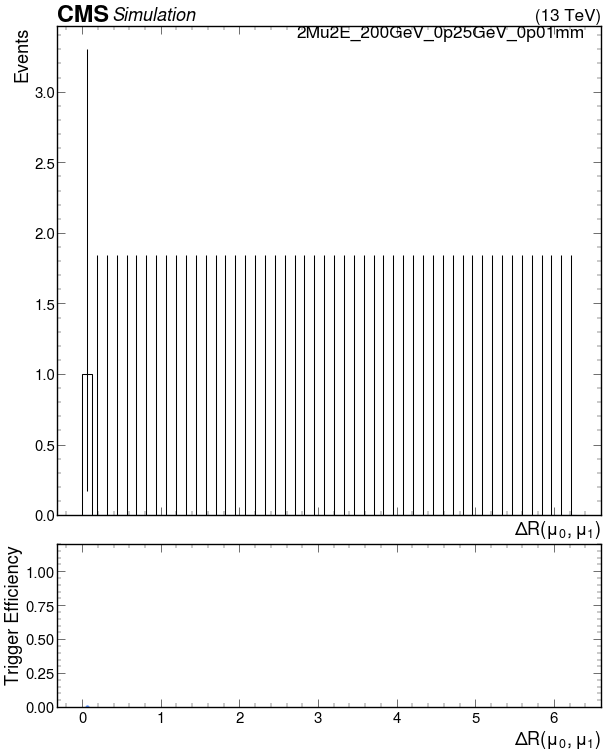

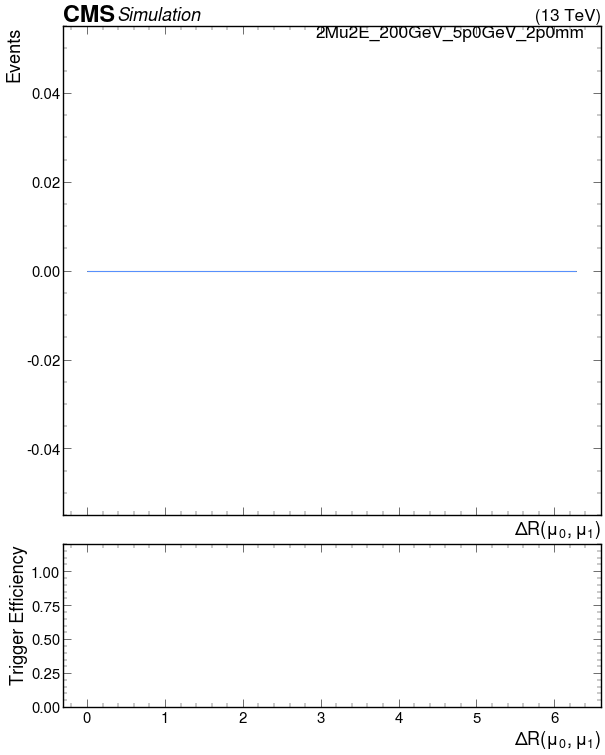

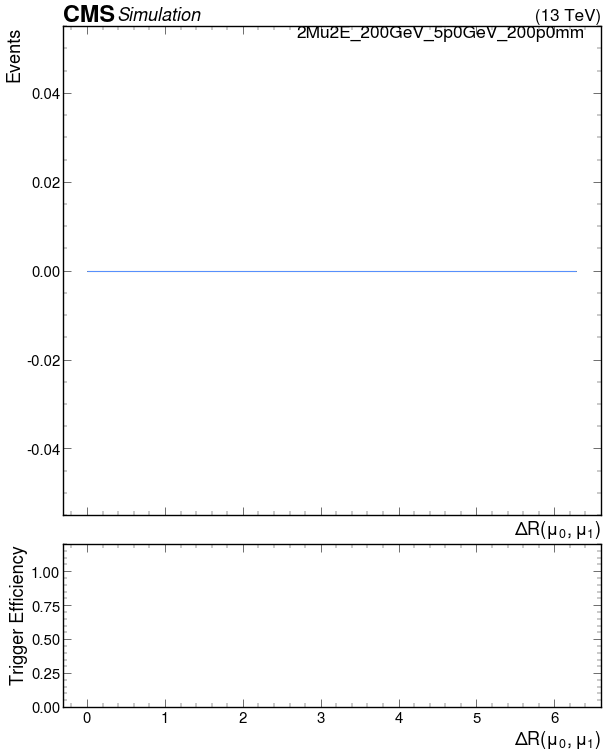

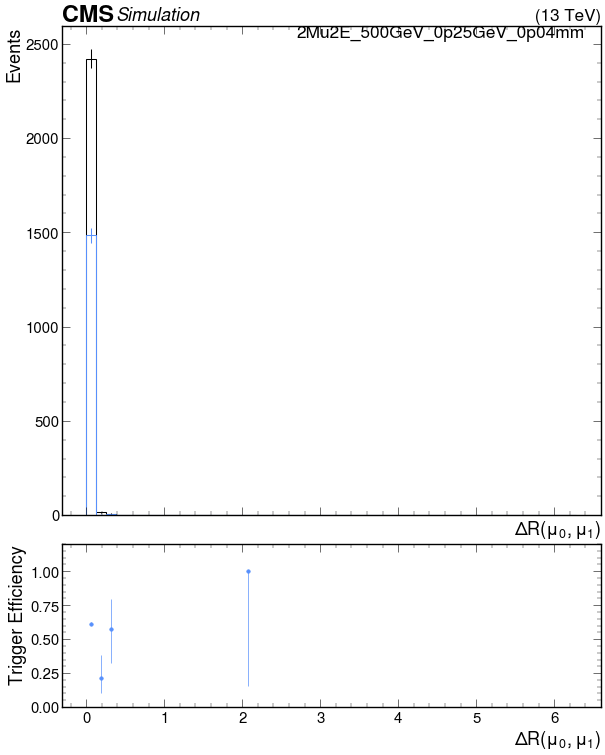

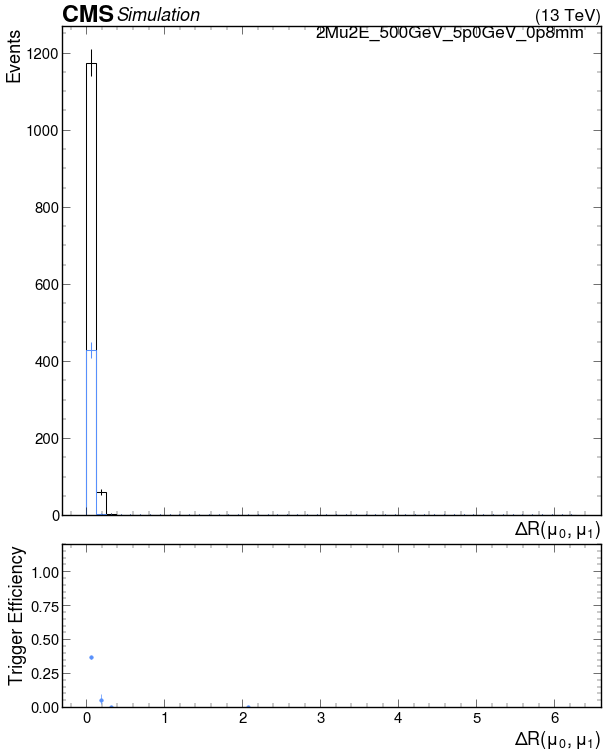

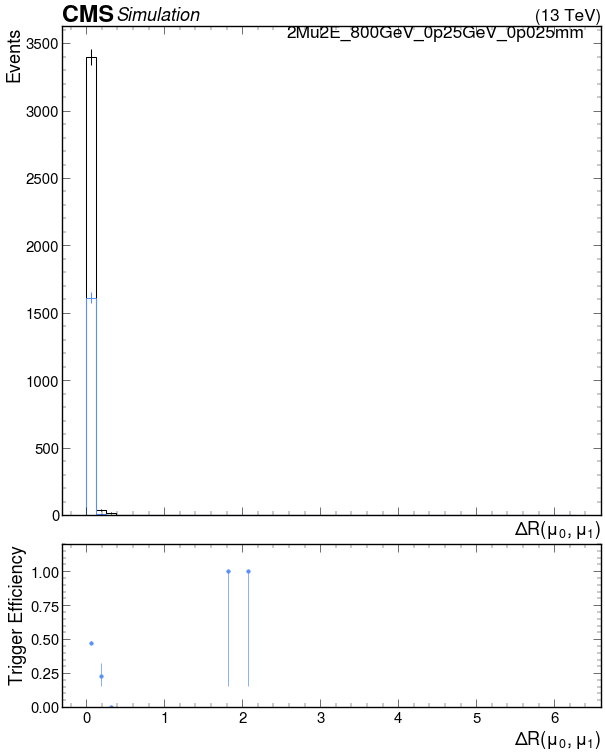

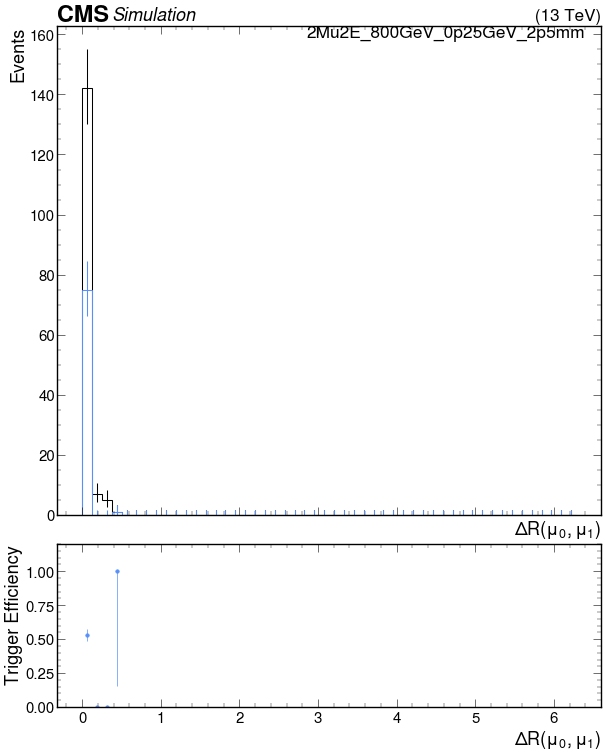

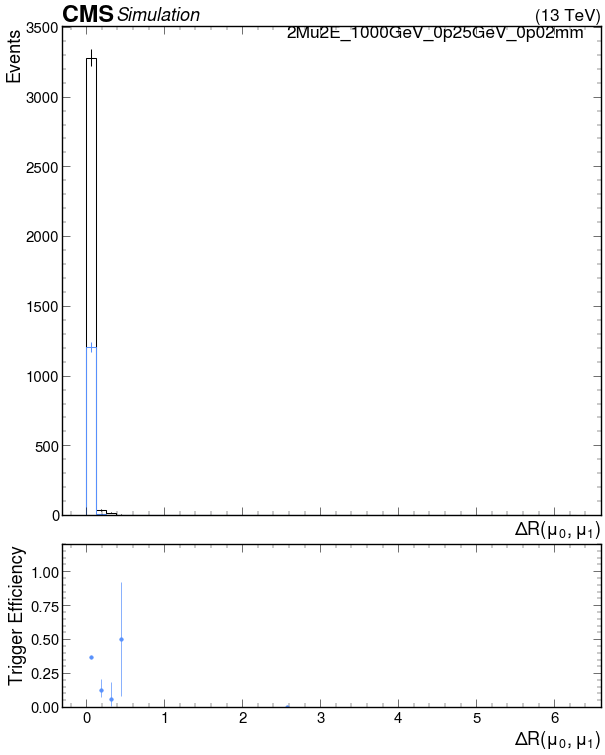

In [8]:
num_ch = "2mu2e_PhotonNumerator"
denom_ch = "2mu2e_PhotonDenominator"
plot_name = "all_muon_dR"

for sample in samples:
    
    nums = [out[sample]["hists"][plot_name][num_ch, :]]
    denoms = [out[sample]["hists"][plot_name][denom_ch, :]]
    
    plot_ratio_row(
        nums, 
        denoms, 
        sample, 
        xlabel=r"$\Delta R(\mu_0, \mu_1)$",
        ylabel="Events",
        ratio_ylabel="Trigger Efficiency"
    )